Prédictions :
[1.81097766 1.67392338 1.62227583 1.56195617 1.52571739 1.42734972
 1.38368606 1.34303659 1.34106415 1.3430849  1.34859857 1.36259526
 1.39648315 1.40692615 1.45118262 1.51079404 1.54319118 1.6327811
 1.64976736 1.69127115 1.78212932 2.36615895 2.16504931]


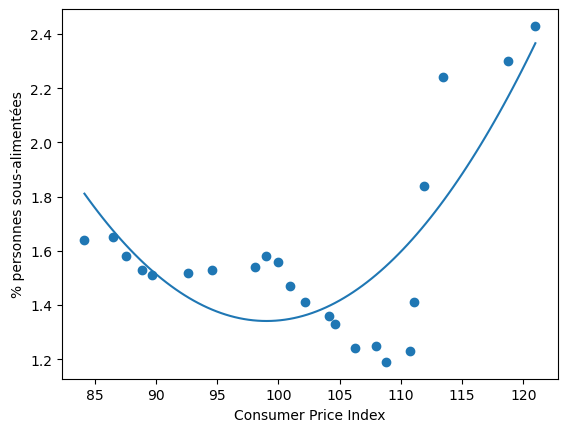

In [3]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt
import numpy as np

# lecture du fichier CSV contenant les données
data = pd.read_csv("../data/data_nutrition.csv")

# choix de la variable explicative (feature)
features = 'Consumer_Price_Index_in_percent'

# variable cible (ce qu'on veut prédire)
target = 'Number_of_Undernourished_People_in_percent'


# extraction de X (doit être sous forme de DataFrame pour sklearn)
X = data[[features]]

# extraction de Y (variable cible)
Y = data[target]


# transformation polynomiale
# ici on crée automatiquement : [1, x, x²]
poly = PolynomialFeatures(degree=2)

# transformation de X en X_poly
X_poly = poly.fit_transform(X)

# création du modèle de régression
model = LinearRegression()

# apprentissage du modèle (trouve les meilleurs coefficients beta)
model.fit(X_poly, Y)

# prédictions sur les données d'entraînement
y_pred = model.predict(X_poly)

print("Prédictions :")
print(y_pred)


# affichage des points réels (scatter = nuage de points)
plt.scatter(X, Y)

# création d'un ensemble de valeurs continues de X (Les valeurs générées peuvent inclure des points déjà présents
#dans le dataset, mais aussi de nouvelles valeurs intermédiaires. 
# np.linspace génère 100 valeurs entre la valeur minimale et maximale de X
# c'est pour obtenir une courbe lisse et continue lors de l'affichage
X_range = pd.DataFrame(
    np.linspace(X.min(), X.max(), 100),
    columns=[features]  
)

# transformation polynomiale des nouvelles valeurs
# le modèle a été entraîné sur des variables transformées (x, x²)
# donc on applique la même transformation sur X_range pour rester cohérent
X_range_poly = poly.transform(X_range)

# prédictions sur ces valeurs continues
# pour chaque valeur de X_range, le modèle calcule une prédiction selon : y = β0 + β1*x + β2*x²
# cela permet d'obtenir les points nécessaires pour tracer la courbe du modèle
y_range = model.predict(X_range_poly)


# affichage de la courbe polynomiale
plt.plot(X_range, y_range, label="Courbe polynomiale")
# noms des axes
plt.xlabel("Consumer Price Index")
plt.ylabel("% personnes sous-alimentées")
# afficher le graphique final
plt.show()